In [35]:
import sys
sys.path.insert(0, "/staging/leuven/stg_00002/lcb/gpartel/software/deepSCENIC")
import os
import torch
import numpy as np
import scanpy as sc
import pandas as pd
import argparse
import json
from skimage import filters
import matplotlib.pyplot as plt
import seaborn as sns

from src.deepSCENIC import deepSCENIC

### Load deepSCENIC model

In [2]:
# Output dir of deepSCENIC
RES_PATH = '/lustre1/project/stg_00002/lcb/gpartel/projects/deepSCENIC/results/DPCL/'
parser = argparse.ArgumentParser()
opt = parser.parse_args('')
with open(RES_PATH + "/hyperparma.txt", 'r') as f:
            opt.__dict__.update(json.load(f))

In [3]:
# Compile model
model = deepSCENIC(opt)
dataloader, _, TFs_idx, r2g_dist_coo, seq_dataloader, _ = model.init_data()

dir exist
reading data...
data read!
AnnData object with n_obs × n_vars = 4000 × 15293
    var: 'n_cells'
    uns: 'log1p'
    layers: 'log_norm'
AnnData object with n_obs × n_vars = 4000 × 365922
False


### Extract TF2r (TF to region: E1) and r2g (region to gene: E2) matrix

In [4]:
from src.model import VAE
from src.tf2rNet.models import MotifNet, Sei
from tqdm import tqdm
import pickle

model.opt.split_test = False
model.opt.train = False
vae_model_path= RES_PATH + '/model.pth'
tf2r_model_path = RES_PATH + '/model_tf2r.pth'
tf2r_func_enc_model_path = RES_PATH + '/model_tf2r_encoder.pth'

if opt.device=='cuda':
    Tensor = torch.cuda.FloatTensor
elif opt.device=='cpu':
    Tensor = torch.FloatTensor

# adj_E1s = []
# for i in range(10):
with torch.no_grad():
    # Initialize TF2rNet model
    with open(opt.ppms_file, 'rb') as f:
        PPMs = pickle.load(f)
    model_dict_tf2rNet = torch.load(tf2r_model_path,  map_location=torch.device(opt.device))['model_state_dict']
    if not opt.enformer_embs_file:
        model_dict_tf2r_func_enc = torch.load(tf2r_func_enc_model_path,  map_location=torch.device(opt.device))['model_state_dict']
        # Initialize tf2rNet cnn
        tf2rNet_func_encoder = Sei().float().to(opt.device)
        tf2rNet = MotifNet(PPMs, model.TFs, opt.TF2rNet_bottleneck_size, emb_len=opt.emb_len, explain=False, dev=opt.device).float().to(opt.device)
        tf2rNet_func_encoder.load_state_dict(model_dict_tf2r_func_enc)
        tf2rNet.load_state_dict(model_dict_tf2rNet)
        tf2rNet_func_encoder.eval()
    else:
        tf2rNet = MotifNet(PPMs, model.TFs, opt.TF2rNet_bottleneck_size, emb_len=opt.emb_len, explain=False, dev=opt.device).float().to(opt.device)
        tf2rNet.load_state_dict(model_dict_tf2rNet)

    tf2rNet.eval()
    # TF2rNet forward pass
    tf_pred_l = []
    tf_pred_mtf_l = []
    tf_pred_ctx_l = []
    for j, (X, seq_data_batch_idx) in tqdm(enumerate(seq_dataloader, 0), total=len(seq_dataloader)):
        tf_pred_mtf = tf2rNet(seq=X[0].to(opt.device), motif=True)
        if not opt.enformer_embs_file:
            tf_pred_ctx = tf2rNet_func_encoder(X[0].to(opt.device))
            tf_pred_ctx = tf2rNet(emb=tf_pred_ctx, motif=False)
        else:
            tf_pred_ctx = tf2rNet(emb=X[1].to(opt.device), motif=False)
        tf_pred_ctx_l.append(tf_pred_ctx)
        tf_pred_mtf_l.append(tf_pred_mtf)
    adj_E1_mtf = torch.cat(tf_pred_mtf_l).T
    adj_E1_ctx = torch.cat(tf_pred_ctx_l).T
    adj_E1 = adj_E1_mtf * adj_E1_ctx

with torch.no_grad():
    vae = VAE(TFs_idx, r2g_dist_coo, 1, model.opt.n_hidden, dev=opt.device).float()
    vae.load_state_dict(torch.load(vae_model_path,  map_location=torch.device('cpu'))['model_state_dict'])

100%|██████████| 2859/2859 [05:23<00:00,  8.84it/s]


In [5]:
E1 = pd.DataFrame(adj_E1.detach().cpu().numpy(), columns=dataloader['atac_region_name'], index=np.array(dataloader['rna_gene_name'])[TFs_idx])
E1_ctx = pd.DataFrame(adj_E1_ctx.detach().cpu().numpy(), columns=dataloader['atac_region_name'], index=np.array(dataloader['rna_gene_name'])[TFs_idx])
E1_mtf = pd.DataFrame(adj_E1_mtf.detach().cpu().numpy(), columns=dataloader['atac_region_name'], index=np.array(dataloader['rna_gene_name'])[TFs_idx])

In [6]:
with torch.no_grad():
    E2 = torch.sparse_coo_tensor(vae.r2g_dist.indices().to(opt.device), vae.adj_E2.abs(), vae.r2g_dist.shape).to_dense()
    E2 = pd.DataFrame(E2.cpu().numpy(), columns=dataloader['rna_gene_name'], index=dataloader['atac_region_name'])
    

In [13]:
# Save matrices
E1.to_pickle(RES_PATH + 'E1.pkl')
E1_mtf.to_pickle(RES_PATH + 'E1_mtf.pkl')
E1_ctx.to_pickle(RES_PATH + 'E1_ctx.pkl')
E2.to_pickle(RES_PATH + 'E2.pkl')

# Extract TF, enhancer activities and other latent representations

In [7]:
model.to_latent(vae_model_path=RES_PATH + 'model.pth', tf2r_model_path = RES_PATH + 'model_tf2r.pth', tf2r_func_enc_model_path=RES_PATH + 'model_tf2r_encoder.pth')

reading data...
data read!
AnnData object with n_obs × n_vars = 4000 × 15293
    var: 'n_cells'
    uns: 'log1p'
    layers: 'log_norm'
AnnData object with n_obs × n_vars = 4000 × 365922
False


2859it [05:11,  9.17it/s]
2859it [00:15, 187.20it/s]

VAE forward...



100%|██████████| 250/250 [00:32<00:00,  7.73batch/s]


In [13]:
# Read gene expression data and cell annotations
DATA_PATH = '/staging/leuven/stg_00002/lcb/gpartel/projects/deepSCENIC/data/DPCL'

ad = sc.read(opt.data_rna_file)
cells_metadata = pd.read_csv(DATA_PATH + '/cells_metadata.csv', index_col=0)
ad.obs[cells_metadata.columns] = cells_metadata.loc[ad.obs.index,:].values

# Load latent representations
ad.obsm['z_rna'] = np.load(opt.save_name + 'z_rna.npy', allow_pickle=True) # Latent target gene expression
ad.obsm['y_rna'] = np.load(opt.save_name + 'y_rna.npy', allow_pickle=True) # Predicted target gene expression
ad.obsm['y_atac'] = np.load(opt.save_name + 'y_atac.npy', allow_pickle=True) # Predicted chromatin accessibility
ad.obsm['enh_act'] = np.load(opt.save_name + 'z_rna_atac.npy', allow_pickle=True) # Predicted enhancer activity
ad.obsm['tf_act'] = np.load(opt.save_name + 'z_tf_reg.npy', allow_pickle=True) # Predicted TF activity

ad

AnnData object with n_obs × n_vars = 4000 × 15293
    obs: 'GEX_sample_id', 'GEX_leiden', 'ACC_cisTopic_nr_frag', 'ACC_cisTopic_log_nr_frag', 'ACC_cisTopic_nr_acc', 'ACC_cisTopic_log_nr_acc', 'ACC_sample_id', 'ACC_Log_total_nr_frag', 'ACC_Log_unique_nr_frag', 'ACC_Total_nr_frag', 'ACC_Unique_nr_frag', 'ACC_Dupl_nr_frag', 'ACC_Dupl_rate', 'ACC_Total_nr_frag_in_regions', 'ACC_Unique_nr_frag_in_regions', 'ACC_FRIP', 'ACC_TSS_enrichment', 'ACC_barcode', 'ACC_Cell_type', 'ACC_pycisTopic_leiden_10_0.3', 'ACC_Line_type'
    var: 'n_cells'
    uns: 'log1p'
    obsm: 'z_rna', 'y_rna', 'y_atac', 'enh_act', 'tf_act'
    layers: 'log_norm'

         Falling back to preprocessing with `sc.pp.pca` and default params.


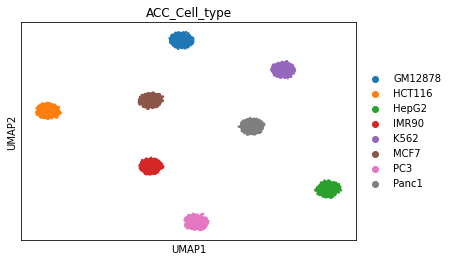

In [14]:
# UMAP of input TF expression
ad_tf = ad[:, TFs_idx].copy()
sc.pp.neighbors(ad_tf, n_pcs=50)
sc.tl.umap(ad_tf)
sc.pl.umap(ad_tf, color=['ACC_Cell_type'])

         Falling back to preprocessing with `sc.pp.pca` and default params.


Graph is not fully connected, spectral embedding may not work as expected.


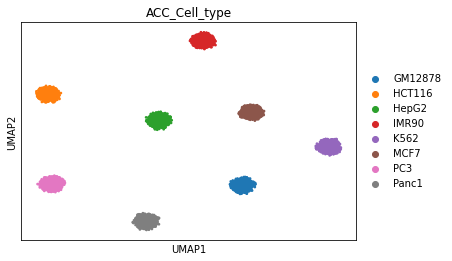

In [15]:
# UMAP of input target gene expression
sc.pp.neighbors(ad, n_pcs=50)
sc.tl.umap(ad)
sc.pl.umap(ad, color=['ACC_Cell_type'])
ad.obsm['X_rna_umap'] = ad.obsm['X_umap']

Graph is not fully connected, spectral embedding may not work as expected.


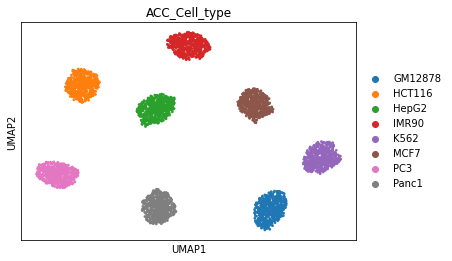

In [12]:
# UMAP of enhancer activity
sc.pp.neighbors(ad, use_rep='enh_act', key_added="enh_act", n_pcs=50)
sc.tl.umap(ad,  neighbors_key='enh_act')
sc.pl.umap(ad, color=['ACC_Cell_type'])
ad.obsm['X_enh_act_umap'] = ad.obsm['X_umap']

### Building eGRN 

Select eRegulons

In [16]:
# Load tfs-regions and regions-genes interaction matrices
# E1 = pd.read_pickle(RES_PATH + 'E1.pkl')
# E2 = pd.read_pickle(RES_PATH + 'E2.pkl')

In [17]:
# Building AnnData objects containing enhancer activity and TFs activity profiles for each cell
ad_enahancer = sc.AnnData(np.load(opt.save_name + 'z_rna_atac.npy', allow_pickle=True), obs=ad.obs)
ad_enahancer.var_names = sc.read(opt.data_atac_file).var_names

ad_tf = sc.AnnData(np.load(opt.save_name + 'z_tf_reg.npy', allow_pickle=True), obs=ad.obs)
ad_tf.var_names = sc.read(opt.data_rna_file).var_names[TFs_idx]

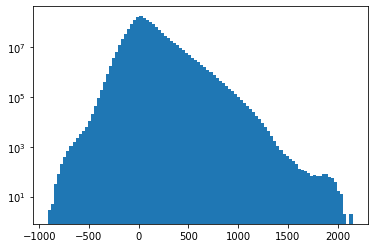

In [18]:
# Plot distribution of enhancer activities
plt.hist(ad_enahancer.X[ad_enahancer.X!=0], bins=100);
plt.yscale('log')

In [19]:
# Building dataframe of enhancer activity profiles per cell-type
df_enancher_activity =[]
for line in ad.obs.ACC_Cell_type.unique():
    df_enancher_activity.append(ad_enahancer[ad_enahancer.obs.ACC_Cell_type==line].to_df().mean(0))
df_enancher_activity = pd.concat(df_enancher_activity, axis=1, keys=ad.obs.ACC_Cell_type.unique())

In [21]:
df_enancher_activity

,IMR90,HCT116,HepG2,K562,MCF7,GM12878,Panc1,PC3
chr10:100001512-100002013,-56.750874,13.702014,14.794542,103.163376,50.827404,-14.770571,78.440010,-44.158886
chr10:100003373-100003874,56.903439,25.363621,12.633429,58.917496,15.221831,59.195744,107.848999,67.711151
chr10:100005207-100005708,53.488209,73.551376,3.259645,83.923256,17.242321,18.985889,140.305710,2.315301
chr10:100005749-100006250,135.345779,-75.947937,-23.719221,-104.864235,-51.059666,-39.055630,2.855270,165.897598
chr10:100007111-100007612,-18.326441,-2.365148,26.319754,55.210159,-18.898434,35.819798,97.843369,-5.471910
...,...,...,...,...,...,...,...,...
chrY:2787087-2787588,42.677891,63.400715,84.436317,136.805145,62.138199,98.552734,127.185089,85.547440
chrY:2935141-2935642,453.141388,262.356537,265.687714,260.048431,233.209793,259.977112,391.872681,362.543549
chrY:2935718-2936219,290.226562,347.561737,291.032898,503.720795,319.300659,478.729065,334.286926,244.286896
chrY:3003837-3004338,-65.685478,98.835548,35.794907,-76.535271,712.382629,462.447021,-61.997555,138.269623


In [22]:
# Threshold enhancer activity profiles per cell-type and compute TFs activity average profiles
df_tf_activity =[]
active_enhancers_l = []
for line in ad.obs.ACC_Cell_type.unique():
    active_enhancers = df_enancher_activity.loc[:, line].abs()
    th = filters.threshold_otsu(active_enhancers.values)
    active_enhancers = active_enhancers[active_enhancers>th]
    active_enhancers_l.append(active_enhancers.index.to_list())
    df_tf_activity.append((ad_tf[ad_tf.obs.ACC_Cell_type==line, :].X.mean(0)[:,None] * E1.loc[:, active_enhancers.index]).abs().mean(1)) # TFs activity average profiles
    
df_tf_activity = pd.concat(df_tf_activity, axis=1, keys=ad.obs.ACC_Cell_type.unique())    

In [25]:
# Threshold TFs activity profiles and extract key TFs per cell-type
TFs = []
for line in ad.obs.ACC_Cell_type.unique():
    df_line = df_tf_activity.loc[:,line].abs()
    th = filters.threshold_otsu(df_line.values)
    TFs.extend(df_line[df_line > th].index.to_list())

# Subset TF-region interaction matrix to key TFs
E1_sub = E1.loc[list(set(TFs)), :]

In [27]:
# Build eGRN
from joblib import Parallel, delayed
from tqdm import tqdm
from skimage import filters

r2g_th=0
def tf_df(E1, E2, tf):
    TFs, regions, target_genes, tf2r_scores, r2g_scores, tf2g_scores = [], [], [], [], [], []

    E1_tf = E1.loc[tf,:][E1.abs().loc[tf,:]>0].abs()
    if E1_tf.shape[0]>0:
        tf2r_th = filters.threshold_otsu(E1_tf.values) # Threshold TF-region interaction scores per TF
        regs = E1.loc[tf,:][E1.abs().loc[tf,:] > tf2r_th].index
        for r in regs:
            E2_r = E2.loc[r, :][E2.loc[r, :]>0]
            if E2_r.shape[0]>0:
                # r2g_th = filters.threshold_otsu(E2_r.values)
                targets = E2.loc[r, :][E2.loc[r, :] > r2g_th].index
                for g in targets:            
                    TFs.append(tf)
                    regions.append(r)
                    target_genes.append(g)
                    tf2r_scores.append(E1.loc[tf,r])
                    tf2g_scores.append(E1.loc[tf,r]*E2.loc[r,g])
                    r2g_scores.append(E2.loc[r,g])

    return TFs, regions, target_genes, tf2r_scores, tf2g_scores, r2g_scores

res = Parallel(n_jobs=32)(delayed(tf_df)(E1_sub, E2, tf) for tf in tqdm(E1_sub.index))

TFs, regions, target_genes, tf2r_scores, tf2g_scores, r2g_scores = [], [], [], [], [], []
for i in tqdm(range(len(res))):
    TFs.extend(res[i][0])
    regions.extend(res[i][1])
    target_genes.extend(res[i][2])
    tf2r_scores.extend(res[i][3])
    tf2g_scores.extend(res[i][4])
    r2g_scores.extend(res[i][5])

df_deepSCENIC_grn = pd.DataFrame({'TF':TFs, 'region':regions, 'gene':target_genes, 'tf2r_score':tf2r_scores, 'tf2g_score':tf2g_scores , 'r2g_score':r2g_scores})
df_deepSCENIC_grn.to_pickle(RES_PATH + '/df_deepSCENIC_grn.pkl')
df_deepSCENIC_grn    

100%|██████████| 662/662 [00:07<00:00, 88.79it/s] 


,TF,region,gene,tf2r_score,tf2g_score,r2g_score
0,THRA,chr10:100014147-100014648,CPN1,-2.982527,-0.016600,0.005566
1,THRA,chr10:100014147-100014648,DNMBP,-2.982527,-0.003860,0.001294
2,THRA,chr10:100014147-100014648,ERLIN1,-2.982527,-0.029677,0.009950
3,THRA,chr10:100020490-100020991,CPN1,-1.717703,-0.019947,0.011612
4,THRA,chr10:100020490-100020991,DNMBP,-1.717703,-0.004912,0.002860
...,...,...,...,...,...,...
142160434,LHX2,chrX:9997522-9998023,SHROOM2,3.911225,0.005450,0.001393
142160435,LHX2,chrX:9997522-9998023,WWC3,3.911225,0.061583,0.015745
142160436,LHX2,chrY:12904540-12905041,USP9Y,2.896938,0.096259,0.033228
142160437,LHX2,chrY:3003837-3004338,RPS4Y1,6.661338,0.000794,0.000119


### Extract differentially active enhancers between cell-type

In [28]:
ad_enahancer_act = ad_enahancer.copy() # Extract positive enhancers
ad_enahancer_act.X[ad_enahancer_act.X < 0]=0

ad_enahancer_rep = ad_enahancer.copy() # Extract negative enhancers
ad_enahancer_rep.X[ad_enahancer_rep.X > 0]=0
ad_enahancer_rep.X = np.abs(ad_enahancer_rep.X)

# Compute differential analysis between cell-types
sc.tl.rank_genes_groups(ad_enahancer_act, 'ACC_Cell_type', method='wilcoxon')
sc.tl.rank_genes_groups(ad_enahancer_rep, 'ACC_Cell_type', method='wilcoxon')

overflow encountered in expm1
overflow encountered in expm1
overflow encountered in divide
invalid value encountered in divide
divide by zero encountered in log2
overflow encountered in expm1
overflow encountered in expm1
invalid value encountered in divide
divide by zero encountered in log2
overflow encountered in expm1
overflow encountered in expm1
overflow encountered in divide
invalid value encountered in divide
divide by zero encountered in log2
overflow encountered in expm1
overflow encountered in expm1
invalid value encountered in divide
divide by zero encountered in log2
overflow encountered in expm1
overflow encountered in expm1
overflow encountered in divide
invalid value encountered in divide
divide by zero encountered in log2
overflow encountered in expm1
overflow encountered in expm1
invalid value encountered in divide
divide by zero encountered in log2
overflow encountered in expm1
overflow encountered in expm1
invalid value encountered in divide
divide by zero encountere

In [29]:
# Differntially positve enhancers
DE_enahncer_act = pd.DataFrame(ad_enahancer_act.uns['rank_genes_groups']['names'])
DE_enahncer_act.index = ad_enahancer_act.var_names
DE_enahncer_act

,GM12878,HCT116,HepG2,IMR90,K562,MCF7,PC3,Panc1
chr10:100001512-100002013,chr2:33321390-33321891,chr3:159322301-159322802,chr9:83526885-83527386,chr20:19252609-19253110,chr21:32572518-32573019,chr3:129506347-129506848,chr4:158155718-158156219,chr1:228366951-228367452
chr10:100003373-100003874,chr3:12730461-12730962,chr7:108097637-108098138,chr8:17506595-17507096,chr4:53119552-53120053,chr20:37850716-37851217,chr9:136725639-136726140,chr2:15337957-15338458,chr20:6122269-6122770
chr10:100005207-100005708,chr3:127483881-127484382,chr7:129163771-129164272,chr1:27607219-27607720,chr6:3805704-3806205,chr6:154444091-154444592,chr6:139343127-139343628,chr14:54105680-54106181,chr20:6133292-6133793
chr10:100005749-100006250,chr13:45538356-45538857,chr10:73965268-73965769,chr10:89645697-89646198,chr2:46379197-46379698,chr20:375227-375728,chr2:105378320-105378821,chr17:45319211-45319712,chr10:90870831-90871332
chr10:100007111-100007612,chr1:18539127-18539628,chr7:66835862-66836363,chr11:93492940-93493441,chr4:53101216-53101717,chr10:49594064-49594565,chr10:59865060-59865561,chr14:54098487-54098988,chr1:100538035-100538536
...,...,...,...,...,...,...,...,...
chrY:2787087-2787588,chr19:51296177-51296678,chr7:35687147-35687648,chr12:56150291-56150792,chr16:18414132-18414633,chr1:174626037-174626538,chr16:75209202-75209703,chr17:67629308-67629809,chr18:23422893-23423394
chrY:2935141-2935642,chr19:5129341-5129842,chr14:88553641-88554142,chr1:180482528-180483029,chr9:110058238-110058739,chr1:151494701-151495202,chr12:25307766-25308267,chr17:66548645-66549146,chr16:47492885-47493386
chrY:2935718-2936219,chr19:512351-512852,chr14:77965884-77966385,chr6:170449180-170449681,chr15:63166217-63166718,chr9:96420432-96420933,chr12:1811459-1811960,chr17:66391513-66392014,chr16:53755437-53755938
chrY:3003837-3004338,chr19:5117337-5117838,chr14:77641917-77642418,chr2:237695305-237695806,chr12:83261922-83262423,chr1:109516871-109517372,chr9:37464042-37464543,chr22:45531767-45532268,chr2:237540749-237541250


In [30]:
# Differntially negative enhancers
DE_enahncer_rep = pd.DataFrame(ad_enahancer_rep.uns['rank_genes_groups']['names'])
DE_enahncer_rep.index = ad_enahancer_rep.var_names
DE_enahncer_rep

,GM12878,HCT116,HepG2,IMR90,K562,MCF7,PC3,Panc1
chr10:100001512-100002013,chr1:179815925-179816426,chr20:59839717-59840218,chr2:31960800-31961301,chr17:49480745-49481246,chr19:44638714-44639215,chr2:218271979-218272480,chr6:36430335-36430836,chr13:74129838-74130339
chr10:100003373-100003874,chr16:70590762-70591263,chr3:24353202-24353703,chr3:24299241-24299742,chr12:132186707-132187208,chr2:85356895-85357396,chr8:67821846-67822347,chr5:69454930-69455431,chr17:31052202-31052703
chr10:100005207-100005708,chr16:70591744-70592245,chr1:93329232-93329733,chr21:41780637-41781138,chr5:62719884-62720385,chr17:58242236-58242737,chr6:36545795-36546296,chr4:140729431-140729932,chr6:110491622-110492123
chr10:100005749-100006250,chr8:142763093-142763594,chr8:17962908-17963409,chr7:103934226-103934727,chr7:6466529-6467030,chr11:11607679-11608180,chr20:25626174-25626675,chr6:110897132-110897633,chr1:52635520-52636021
chr10:100007111-100007612,chr17:74949420-74949921,chr10:101690318-101690819,chr16:79007426-79007927,chr20:34808490-34808991,chr6:170224741-170225242,chr4:112550670-112551171,chr2:85614578-85615079,chr11:67230300-67230801
...,...,...,...,...,...,...,...,...
chrY:2787087-2787588,chr17:68182033-68182534,chr11:9357645-9358146,chr3:149653484-149653985,chr6:131213397-131213898,chr6:53539493-53539994,chr6:53799439-53799940,chr8:106388932-106389433,chr1:15789594-15790095
chrY:2935141-2935642,chr11:77725317-77725818,chr5:45205557-45206058,chr3:186804675-186805176,chr18:21117372-21117873,chr1:193067964-193068465,chr1:7326270-7326771,chr2:204634189-204634690,chr7:121086402-121086903
chrY:2935718-2936219,chr5:131250840-131251341,chr1:207315529-207316030,chr10:63719209-63719710,chr7:121525426-121525927,chr6:50959101-50959602,chr6:27888637-27889138,chr10:60719576-60720077,chr1:150712763-150713264
chrY:3003837-3004338,chr7:137895548-137896049,chr20:62087743-62088244,chr3:66852176-66852677,chr17:58657464-58657965,chr6:49646118-49646619,chr2:36616910-36617411,chr2:203559582-203560083,chr19:1032471-1032972


In [31]:
n_enhancers = 100
markers = []
for line in ad.obs.ACC_Cell_type.unique():
    # markers.append(df_enancher_activity.loc[:,line].sort_values(ascending=False)[:n_enhancers].index.values)
    markers.append(DE_enahncer_act.loc[:,line][:n_enhancers].values)

### Extract keys TFs per cell-type

1. Most active TFs in differentially active enhancers

In [32]:
# Extract TF activities on top DA positive enhancers per cell-type
n_enhancers = 3000
df_tf_activity =[]
for line in ad.obs.ACC_Cell_type.unique():
    df_tf_activity.append((ad_tf[ad_tf.obs.ACC_Cell_type==line, :].X.mean(0)[:,None] * E1.loc[:, DE_enahncer_act.loc[:, line][:n_enhancers]]).mean(1))

df_tf_activity = pd.concat(df_tf_activity, axis=1, keys=ad.obs.ACC_Cell_type.unique())    

In [33]:
# Extract top activators per cell-type
n_TFs = 20
markers = []
for line in ad.obs.ACC_Cell_type.unique():
    markers.append(df_tf_activity.loc[:,line].sort_values(ascending=False)[:n_TFs].index.values)

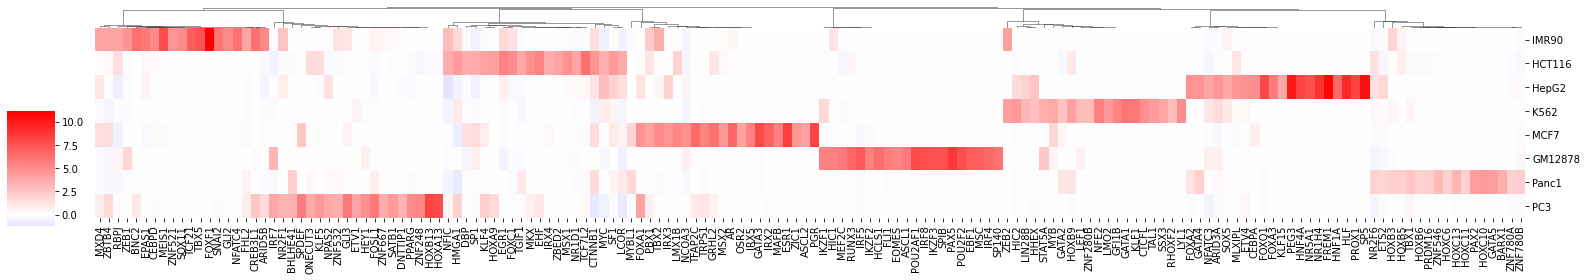

In [36]:
sns.clustermap(df_tf_activity.loc[list(set(np.concatenate(markers))), :].T,
               row_cluster=False, 
               cmap='bwr', 
               center=0, 
               figsize=(22,4), 
               xticklabels=True, 
               dendrogram_ratio=(0.05, .1),
               cbar_pos=(0, .2, .03, .4),
               method='average',
               metric='correlation')

In [37]:
# Extract TF activities on top DA negative enhancers per cell-type
n_enhancers = 3000
df_tf_activity =[]
for line in ad.obs.ACC_Cell_type.unique():
    df_tf_activity.append((ad_tf[ad_tf.obs.ACC_Cell_type==line, :].X.mean(0)[:,None] * E1.loc[:, DE_enahncer_rep.loc[:, line][:n_enhancers]]).mean(1))
df_tf_activity = pd.concat(df_tf_activity, axis=1, keys=ad.obs.ACC_Cell_type.unique())    

In [38]:
# Extract top repressors per cell-type
n_TFs = 20
markers = []
for line in ad.obs.ACC_Cell_type.unique():
    markers.append(df_tf_activity.loc[:,line].sort_values(ascending=True)[:n_TFs].index.values)

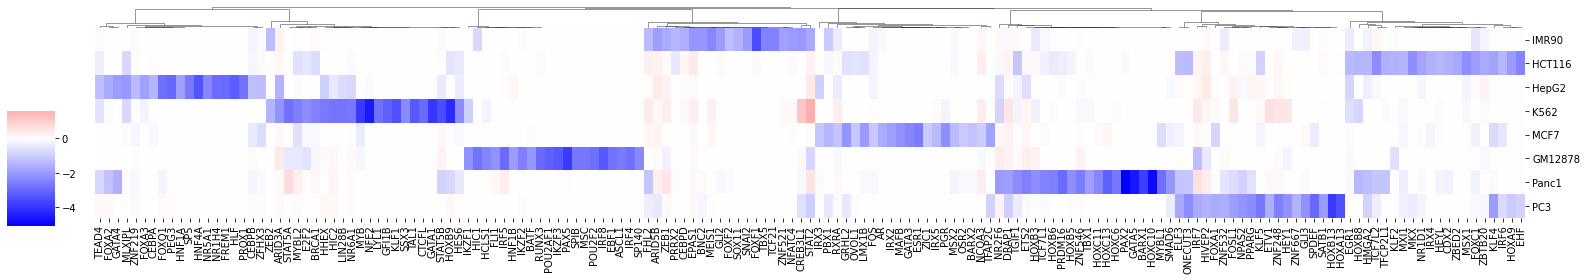

In [39]:
sns.clustermap(df_tf_activity.loc[list(set(np.concatenate(markers))), :].T,
               row_cluster=False, 
               cmap='bwr', 
               center=0, 
               figsize=(22,4), 
               xticklabels=True, 
               dendrogram_ratio=(0.05, .1),
               cbar_pos=(0, .2, .03, .4),
               method='average',
               metric='correlation')

2. Extract key TFs in most active enhacers per cell type

In [40]:
# Extract TF activities on top positive enhancers per cell-type
n_enhancers = 3000
df_tf_activity =[]
for line in ad.obs.ACC_Cell_type.unique():
    active_enhancers = ad_enahancer[ad_enahancer.obs.ACC_Cell_type==line].to_df().mean(0).sort_values(ascending=False)[:n_enhancers]
    df_tf_activity.append((ad_tf[ad_tf.obs.ACC_Cell_type==line, :].X.mean(0)[:,None] * E1.loc[:, active_enhancers.index]).mean(1))
df_tf_activity = pd.concat(df_tf_activity, axis=1, keys=ad.obs.ACC_Cell_type.unique())    

In [41]:
# Extract top activators per cell-type
n_TFs = 20
markers = []
for line in ad.obs.ACC_Cell_type.unique():
    markers.append(df_tf_activity.loc[:,line].sort_values(ascending=False)[:n_TFs].index.values)

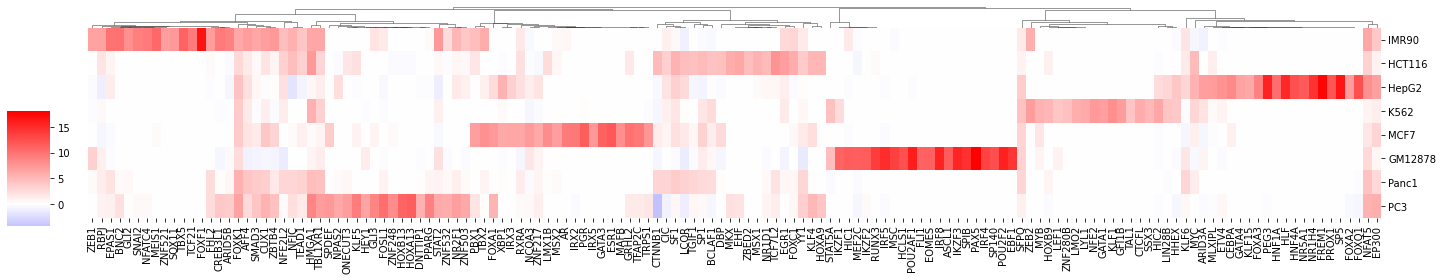

In [42]:
sns.clustermap(df_tf_activity.loc[list(set(np.concatenate(markers))), :].T,
               row_cluster=False, 
               cmap='bwr', 
               center=0, 
               figsize=(20,4), 
               xticklabels=True, 
               dendrogram_ratio=(0.05, .1),
               cbar_pos=(0, .2, .03, .4),
               method='average',
               metric='correlation')

In [43]:
# Extract TF activities on top negative enhancers per cell-type
df_tf_activity =[]
for line in ad.obs.ACC_Cell_type.unique():
    active_enhancers = ad_enahancer[ad_enahancer.obs.ACC_Cell_type==line].to_df().mean(0).sort_values(ascending=True)[:n_enhancers]
    df_tf_activity.append((ad_tf[ad_tf.obs.ACC_Cell_type==line, :].X.mean(0)[:,None] * E1.loc[:, active_enhancers.index]).mean(1))
df_tf_activity = pd.concat(df_tf_activity, axis=1, keys=ad.obs.ACC_Cell_type.unique())    

In [44]:
# Extract top repressors per cell-type
markers = []
for line in ad.obs.ACC_Cell_type.unique():
    markers.append(df_tf_activity.loc[:,line].sort_values(ascending=True)[:n_TFs].index.values)

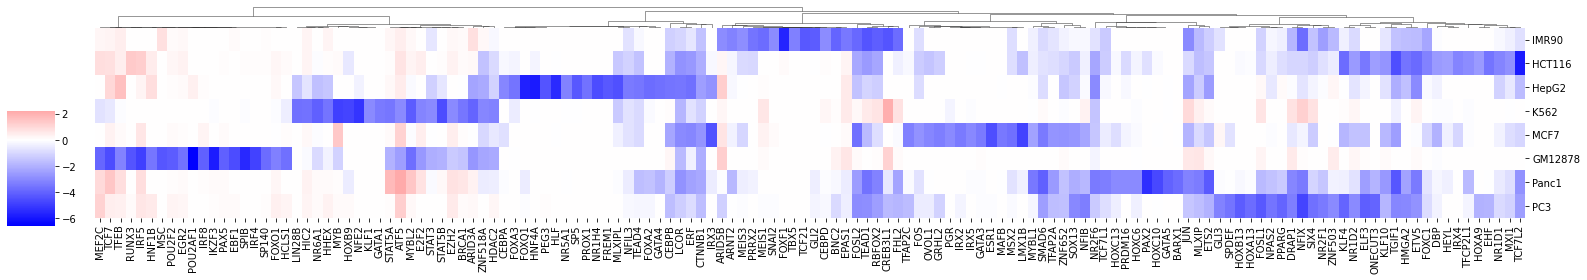

In [45]:
sns.clustermap(df_tf_activity.loc[list(set(np.concatenate(markers))), :].T,
               row_cluster=False, 
               cmap='bwr', 
               center=0, 
               figsize=(22,4), 
               xticklabels=True, 
               dendrogram_ratio=(0.05, .1),
               cbar_pos=(0, .2, .03, .4),
               method='average',
               metric='correlation')

# Coverage plots

In [46]:
#path to fragments files
import os
DATA_PATH = '/lustre1/project/stg_00002/lcb/gpartel/projects/deepSCENIC/data/DPCL/'
fragments_dict = {
    'DPCL': '/staging/leuven/stg_00002/lcb/cbravo/Multiomics_pipeline/analysis/DPCL/data/atac_fragments/fragments.sorted.tsv.gz'}

In [51]:
# Import scenicplus object
import dill
scplus_obj = dill.load(open('/lustre1/project/stg_00002/lcb/gpartel/projects/deepSCENIC/data/DPCL/scplus_obj.pkl', 'rb'))

In [49]:
# Generate bigWig files of enhancer activities
from src.utils import generate_bigWig
for line in df_enancher_activity.columns:
    print(line)
    generate_bigWig(df_enancher_activity.index, df_enancher_activity.loc[:,line], chrs_size_file='/staging/leuven/stg_00002/lcb/resources/human/hg38/hg38.chrom.sizes', save_dir=RES_PATH+line)

IMR90

Creating dataframe...

           Chromosome  Start        End
0                chr1      0  248956422
1                chr2      0  242193529
2                chr3      0  198295559
3                chr4      0  190214555
4                chr5      0  181538259
..                ...    ...        ...
450  chrUn_KI270539v1      0        993
451  chrUn_KI270385v1      0        990
452  chrUn_KI270423v1      0        981
453  chrUn_KI270392v1      0        971
454  chrUn_KI270394v1      0        970

[455 rows x 3 columns]
+--------------+-----------+-----------+--------------------+
| Chromosome   | Start     | End       | Score              |
| (category)   | (int32)   | (int32)   | (float32)          |
|--------------+-----------+-----------+--------------------|
| chr1         | 804608    | 805109    | 145.2952880859375  |
| chr1         | 817312    | 817813    | 222.6571502685547  |
| chr1         | 817897    | 818398    | 293.4439697265625  |
| chr1         | 818689    | 819

In [52]:
# Generate bed file of consensus regions
from src.utils import format_region_to_bed

output_file = open(DATA_PATH + '/consensus_peak_calling/consensus_regions.bed', 'w')
[format_region_to_bed(r, output_file) for r in scplus_obj.region_names]
output_file.close()

In [53]:
# Generate interaction and annotation pyranges
import pyranges as pr
from src.utils import get_interaction_pr

bigwig_dir = RES_PATH + '/bigWigs/'
bw_dict_activity = {x.replace('.bw', ''): os.path.join(bigwig_dir, x) for x in os.listdir(bigwig_dir) if '.bw' in x}
bigwig_dir = DATA_PATH + '/consensus_peak_calling/pseudobulk_bw_files/'
bw_dict_atac = {x.replace('.bw', ''): os.path.join(bigwig_dir, x) for x in os.listdir(bigwig_dir) if '.bw' in x}

df_deepSCENIC_r2g = df_deepSCENIC_grn.drop_duplicates(subset=['region', 'gene'])
pr_interact = get_interaction_pr(df_deepSCENIC_r2g, 'hsapiens', 'hg38')
gtf_file = "/lustre1/project/stg_00002/lcb/fderop/data/00000000_genomes/GRCh38_STAR_2.7.5_rna/genes.gtf"
pr_gtf = pr.read_gtf(gtf_file)

pr_consensus_beds = []
for f in os.listdir(DATA_PATH + '/consensus_peak_calling/pseudobulk_bed_files/'):
    pr_consensus_beds.append(pr.read_bed(DATA_PATH + '/consensus_peak_calling/pseudobulk_bed_files/' + f))
pr_consensus_bed = pr.concat(pr_consensus_beds)    

invalid value encountered in divide


<AxesSubplot:>

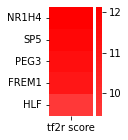

In [54]:
# Select region to display
r= 'chr4:88107462-88107963'
# Extract and visualize top 5 TFs
key_TFs = E1.loc[:, r].abs().sort_values(ascending=False)[:5].index
plt.figure(figsize=(1,2))
sns.heatmap(pd.DataFrame({'tf2r score':E1.loc[key_TFs, r].sort_values(ascending=False)}), cmap='bwr', center=0)

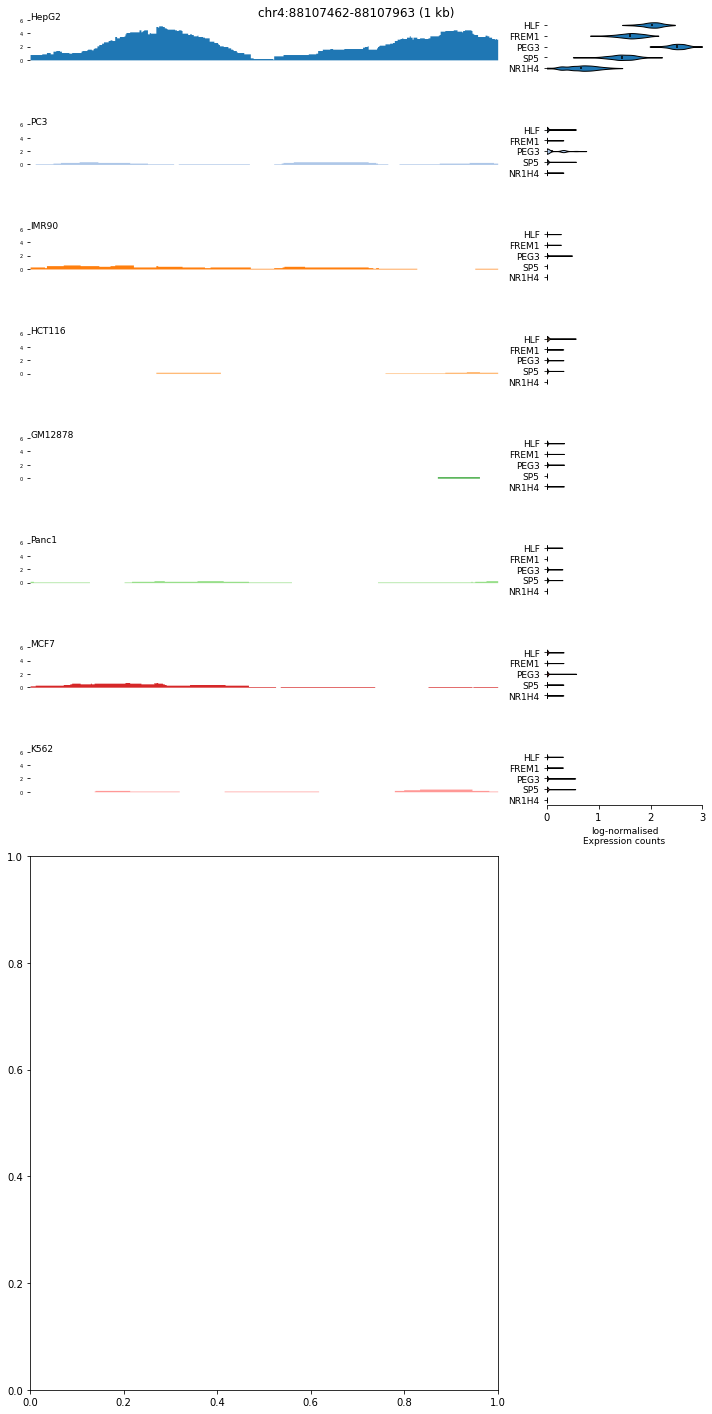

In [56]:
# Plot atac coverage of region
from scenicplus.plotting.coverageplot import coverage_plot

fig = coverage_plot(
        SCENICPLUS_obj = scplus_obj,
        bw_dict = bw_dict_atac,
        region =r,
        figsize = (10,20),
        # pr_gtf = pr_gtf,
        color_dict = None,
        plot_order = None,
        pr_interact = pr_interact,
        genes_violin_plot = key_TFs,
        meta_data_key = 'ACC_Cell_type',
        pr_consensus_bed = pr_consensus_bed,
        # fontsize_dict={'bigwig_label': 12, 'gene_label': 10, 'violinplots_xlabel': 10, 'title': 12, 'bigwig_tick_label': 0, 'violinplots_ylabel': 3},
        height_ratios_dict = {'bigwig_violin': 1, 'genes': 0.5, 'arcs': 10, 'custom_ax': 5})
plt.tight_layout();

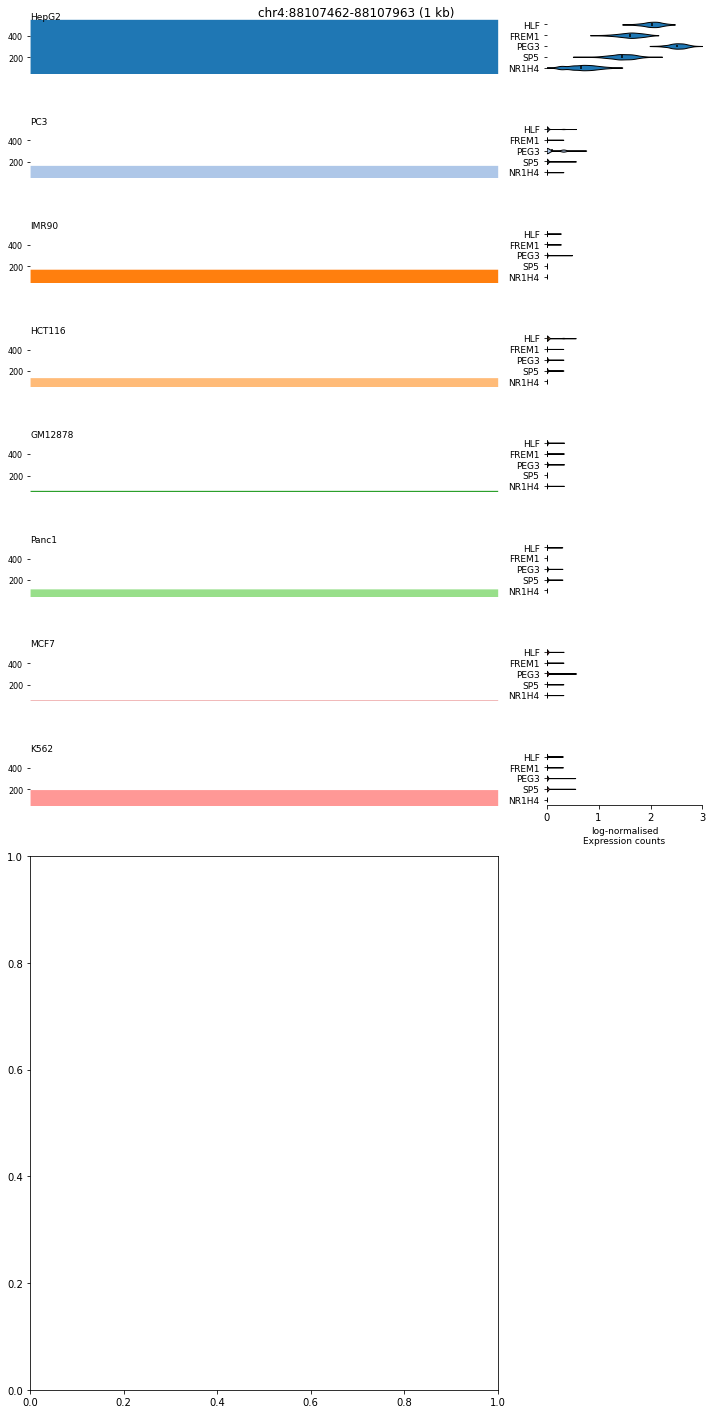

In [57]:
# Plot atac coverage of region
from src.utils import activity_plot

fig = activity_plot(
        SCENICPLUS_obj = scplus_obj,
        bw_dict = bw_dict_activity,
        region =r,
        figsize = (10,20),
        # pr_gtf = pr_gtf,
        color_dict = None,
        plot_order = None,
        pr_interact = pr_interact,
        genes_violin_plot = key_TFs,
        meta_data_key = 'ACC_Cell_type',
        pr_consensus_bed = pr_consensus_bed,
        # fontsize_dict={'bigwig_label': 12, 'gene_label': 10, 'violinplots_xlabel': 10, 'title': 12, 'bigwig_tick_label': 0, 'violinplots_ylabel': 3},
        height_ratios_dict = {'bigwig_violin': 1, 'genes': 0.5, 'arcs': 10, 'custom_ax': 5})
plt.tight_layout();